# Bank Churn Analysis Project

**Student Name:** Riya Tiwari  
**Roll Number:** 00614702024  
**Class:** BCA 4th Semester  
**Instructor:** Dr. Charul Nigam  

---

## Objective & Problem Statement

**Objective:**  
To analyze customer data and identify patterns that influence churn behavior.

**Problem Statement:**  
The goal is to understand which factors contribute to customer churn, and extract insights that can help improve customer retention.

In [3]:
# =========================================
# STEP 1 — IMPORTING LIBRARIES
# =========================================
# pandas  : data manipulation and analysis
# numpy   : numerical computations
# matplotlib : base plotting library
# seaborn : statistical data visualization (built on matplotlib)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn visual style for all plots
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# =========================================
# STEP 2 — DATA COLLECTION & LOADING
# =========================================
# Load the dataset from a CSV file into a pandas DataFrame.
# Display column names, first few rows, data types, and shape
# to get an initial understanding of the dataset.
# =========================================

print("\n========== DATA LOADING ==========\n")

# Load the Churn Modelling dataset
df = pd.read_csv(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\Churn_Modelling.csv")

# Display column names to understand available features
print("Columns in Dataset:\n", df.columns)

# Preview the first 5 rows of the dataset
print("\nFirst 5 Rows:\n", df.head())

# Show data types and non-null counts for each column
print(df.info())

# Display total number of rows and columns
print(df.shape)


========== DATA LOADING ==========

Columns in Dataset:
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

First 5 Rows:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               

In [10]:
# =========================================
# STEP 3 — DATA CLEANING
# =========================================
# In this step we:
#   1. Check for missing (null) values in each column
#   2. Detect and remove duplicate rows
#   3. Drop columns that have no analytical value
#      (RowNumber, CustomerId, Surname are identifiers
#       that do not influence churn prediction)
# =========================================

print("\n========== DATA CLEANING ==========\n")

# --- 3a: Check for missing values ---
print("Missing Values:\n", df.isnull().sum())

# --- 3b: Check and remove duplicate rows ---
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# --- 3c: Drop irrelevant columns (no analytical value) ---
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("\nColumns after dropping unnecessary features:\n", df.columns)


========== DATA CLEANING ==========

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Duplicate rows: 0

Columns after dropping unnecessary features:
 Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')


In [11]:
# =========================================
# STEP 4 — DATA TRANSFORMATION
# =========================================
# Machine learning models require numerical input.
# We apply One-Hot Encoding to convert categorical
# columns ('Geography', 'Gender') into numerical format.
# drop_first=True avoids multicollinearity by dropping
# one dummy variable per category.
# =========================================

print("\n========== DATA TRANSFORMATION ==========\n")

# Convert categorical columns to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Display the first few rows after encoding to verify transformation
print("Data after Encoding:\n", df.head())


========== DATA TRANSFORMATION ==========

Data after Encoding:
    CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1         79084.10       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  
2            False        False 

In [12]:
# =========================================
# STEP 5 — DATA DISCRETIZATION
# =========================================
# Continuous age values are grouped into meaningful
# categories using pd.cut():
#   - Young  : 18 – 30
#   - Adult  : 30 – 50
#   - Senior : 50 – 100
# This helps identify age-group-level churn patterns
# that may not be visible with raw age values.
# =========================================

print("\n========== DATA DISCRETIZATION ==========\n")

# Bin the 'Age' column into three labeled categories
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 50, 100],
    labels=['Young', 'Adult', 'Senior']
)

# Preview Age and its corresponding AgeGroup to confirm correct binning
print("Data with Age Groups:\n", df[['Age', 'AgeGroup']].head())


========== DATA DISCRETIZATION ==========

Data with Age Groups:
    Age AgeGroup
0   42    Adult
1   41    Adult
2   42    Adult
3   39    Adult
4   43    Adult


In [13]:
# =========================================
# STEP 6 — EXPLORATORY DATA ANALYSIS (EDA)
# — Statistical Summary
# =========================================
# Compute descriptive statistics for all numerical columns
# (count, mean, std, min, quartiles, max).
# Focus on Age-specific statistics:
#   Mean, Median, Std Dev, Range, IQR, Skewness, Kurtosis
# =========================================

print("\n========== EXPLORATORY DATA ANALYSIS ==========\n")

# Overall statistical summary of the dataset
print("Statistical Summary:\n", df.describe())

# --- Detailed Age Statistics ---
print("\n--- Age Statistics ---")
print("Mean Age:", df['Age'].mean())                                        # Average age
print("Median Age:", df['Age'].median())                                    # Middle value
print("Standard Deviation:", df['Age'].std())                               # Spread around mean
print("Range:", df['Age'].max() - df['Age'].min())                          # Max - Min
print("IQR:", df['Age'].quantile(0.75) - df['Age'].quantile(0.25))          # Interquartile range
print("Skewness:", df['Age'].skew())                                        # Asymmetry of distribution
print("Kurtosis:", df['Age'].kurt())                                        # Tail heaviness


========== EXPLORATORY DATA ANALYSIS ==========

Statistical Summary:
         CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203

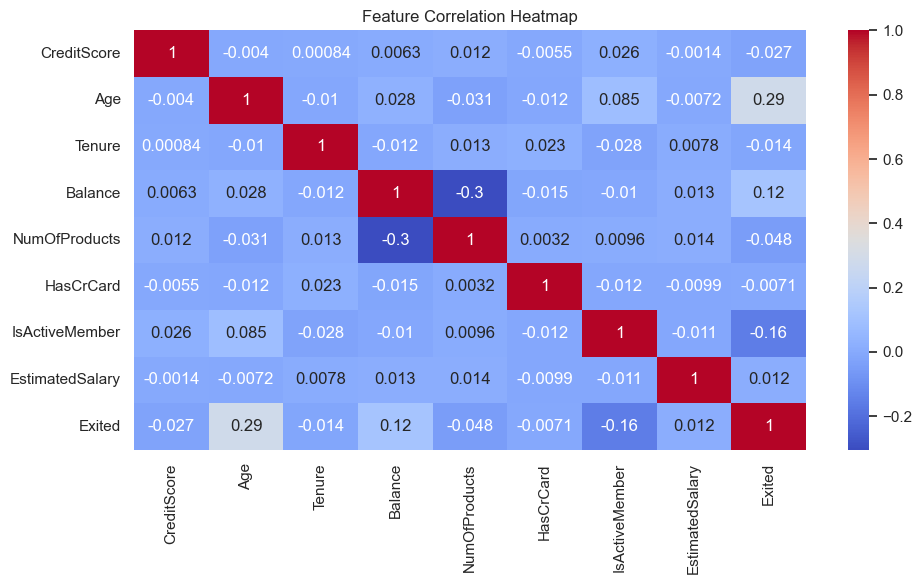

In [15]:
# =========================================
# VISUALIZATION 0 — CORRELATION HEATMAP
# =========================================
# A heatmap of pairwise Pearson correlation coefficients
# for all numeric features helps identify:
#   - Features strongly correlated with 'Exited' (churn)
#   - Multicollinearity between independent features
# 'coolwarm' colormap: blue = negative, red = positive correlation
# =========================================

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

# Save the figure before displaying it
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\correlation_heatmap.png")
plt.show()

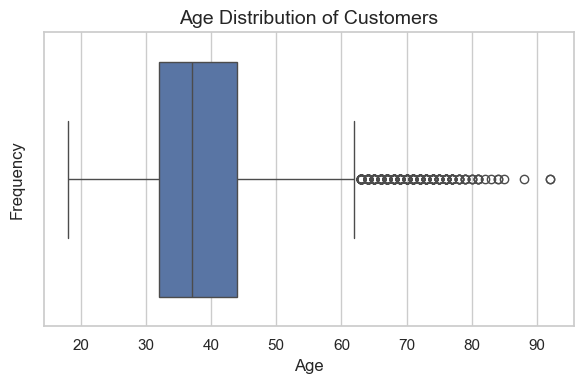


Explanation: The boxplot shows distribution of customer age, presence of outliers, and spread of data.



In [17]:
# =========================================
# VISUALIZATION 1 — AGE DISTRIBUTION (BOXPLOT)
# =========================================
# A boxplot summarizes the distribution of customer ages:
#   - The box represents the IQR (25th to 75th percentile)
#   - The line inside shows the median age
#   - Whiskers extend to 1.5x IQR; points beyond are outliers
# Useful for spotting skewness and extreme age values.
# =========================================

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title("Age Distribution of Customers", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()

# Save figure before showing
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\1.png")
plt.show()

print("\nExplanation: The boxplot shows distribution of customer age, presence of outliers, and spread of data.\n")

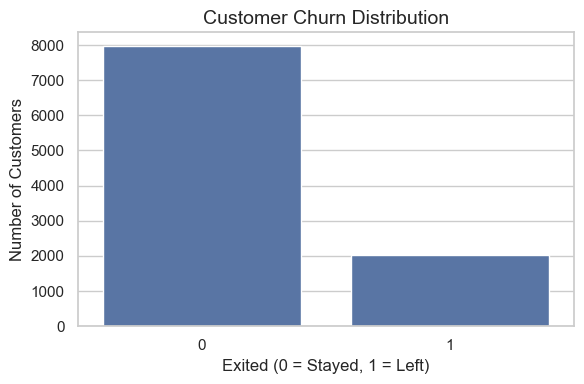

In [19]:
# =========================================
# VISUALIZATION 2 — Customer Churn Distribution
# =========================================
# A count plot to visualize class balance of the target variable:
#   - 0 = Customer Stayed
#   - 1 = Customer Left (Churned)
# An imbalanced dataset can bias model predictions,
# making this a critical first look at the target variable.
# =========================================

plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Exited (0 = Stayed, 1 = Left)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.tight_layout()

# Save figure before showing
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\2.png")
plt.show()

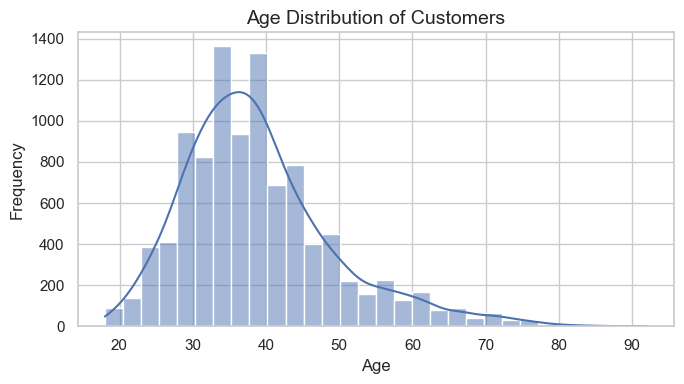

In [21]:
# =========================================
# VISUALIZATION 3 — AGE DISTRIBUTION (Histogram with KDE)
# =========================================
# A histogram with a Kernel Density Estimate (KDE) overlay
# shows the frequency and probability density of customer ages.
#   - Bars represent actual frequency counts
#   - KDE curve smooths out the distribution shape
# Helps identify the most common age ranges among customers.
# =========================================

plt.figure(figsize=(7, 4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Customers", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()

# Save figure before showing
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\3.png")
plt.show()

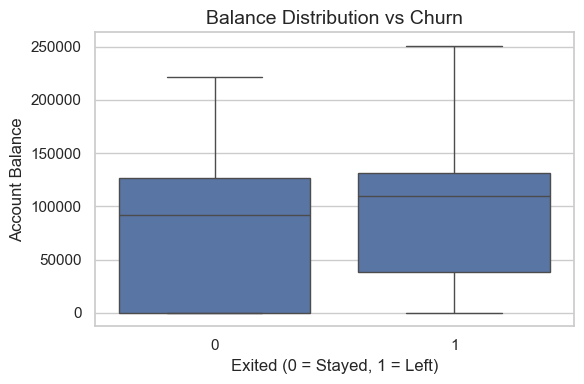

In [23]:
# =========================================
# VISUALIZATION 4 — Balance vs Churn (Key Business Insight)
# =========================================
# A boxplot comparing account balance distributions
# for churned vs retained customers.
# Key Question: Do customers with higher balances churn more?
# This is a critical business insight — high-balance churners
# represent significant revenue loss for the bank.
# =========================================

plt.figure(figsize=(6, 4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance Distribution vs Churn", fontsize=14)
plt.xlabel("Exited (0 = Stayed, 1 = Left)", fontsize=12)
plt.ylabel("Account Balance", fontsize=12)
plt.tight_layout()

# Save figure before showing
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\4.png")
plt.show()

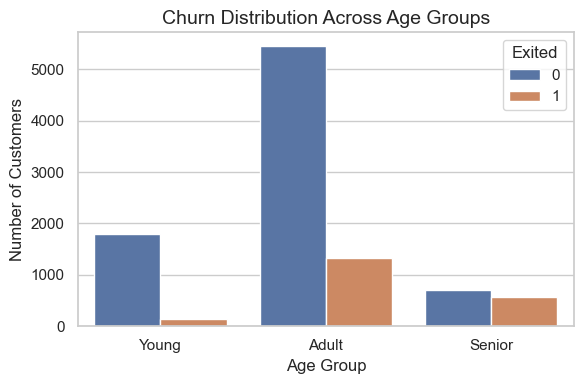

Overall EDA Insights

- Majority customers are middle-aged (30–40)
- Dataset is imbalanced (more non-churn customers)
- Balance and age influence churn behavior
- Certain age groups show higher churn risk



In [25]:
# =========================================
# VISUALIZATION 5 — Age Group vs Churn
# =========================================
# A grouped count plot to compare churn rates
# across the three age groups: Young, Adult, Senior.
# hue='Exited' splits each age group bar by churn status,
# making it easy to compare retention across life stages.
# =========================================

plt.figure(figsize=(6, 4))
sns.countplot(x='AgeGroup', hue='Exited', data=df)
plt.title("Churn Distribution Across Age Groups", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Exited")
plt.tight_layout()

# Save figure before showing
plt.savefig(r"C:\Users\Riya Tiwari\OneDrive\Desktop\Data Science\output\figures\5.png")
plt.show()

# --- Overall EDA Insights ---
print("Overall EDA Insights")
print("""
- Majority customers are middle-aged (30–40)
- Dataset is imbalanced (more non-churn customers)
- Balance and age influence churn behavior
- Certain age groups show higher churn risk
""")

In [26]:
# =========================================
# PIVOT TABLE ANALYSIS
# =========================================
# A pivot table aggregates data to reveal patterns.
# Here we compute the mean account balance grouped by:
#   - rows   : AgeGroup (Young / Adult / Senior)
#   - columns: Exited (0 = Stayed, 1 = Churned)
# This helps answer: "Do churned customers of different
# age groups hold significantly different balances?"
# =========================================

print("\n========== PIVOT TABLE ANALYSIS ==========\n")

# Create pivot table: average balance by AgeGroup and Churn status
pivoted_df = pd.pivot_table(
    df,
    values='Balance',
    index='AgeGroup',
    columns='Exited',
    aggfunc='mean'
)

print("Average Balance by Age Group and Churn:\n", pivoted_df)

print("\nExplanation: This table shows how average balance differs across age groups for customers who stayed vs churned.\n")


========== PIVOT TABLE ANALYSIS ==========

Average Balance by Age Group and Churn:
 Exited               0              1
AgeGroup                             
Young     70835.356083  101436.959247
Adult     73429.948975   90617.618997
Senior    71918.845960   89910.010284

Explanation: This table shows how average balance differs across age groups for customers who stayed vs churned.



In [27]:
# =========================================
# STEP 7 — INSIGHTS & RECOMMENDATIONS
# =========================================
# Summarize key findings from the EDA and provide
# actionable business recommendations based on the analysis.
# =========================================

print("\n========== INSIGHTS ==========\n")

print("""
- The majority of customers fall in the 30–40 age range, indicating a strong middle-aged customer base.
- Age distribution shows a slight right skew due to the presence of older customers (outliers above 60).
- Churn behavior varies across age groups, suggesting age is an important factor in customer retention.
- Customers with lower engagement (e.g., inactivity) are more likely to churn.
- Account balance shows variation between churned and retained customers, indicating financial behavior influences retention.
""")

print("\n========== RECOMMENDATIONS ==========\n")

print("""
- Identify and target high-risk customers based on age and activity patterns.
- Improve engagement strategies such as personalized offers and communication.
- Provide tailored banking services for different age groups.
- Monitor high-balance customers closely to reduce potential revenue loss.
""")


========== INSIGHTS ==========


- The majority of customers fall in the 30–40 age range, indicating a strong middle-aged customer base.
- Age distribution shows a slight right skew due to the presence of older customers (outliers above 60).
- Churn behavior varies across age groups, suggesting age is an important factor in customer retention.
- Customers with lower engagement (e.g., inactivity) are more likely to churn.
- Account balance shows variation between churned and retained customers, indicating financial behavior influences retention.


========== RECOMMENDATIONS ==========


- Identify and target high-risk customers based on age and activity patterns.
- Improve engagement strategies such as personalized offers and communication.
- Provide tailored banking services for different age groups.
- Monitor high-balance customers closely to reduce potential revenue loss.



In [28]:
# =========================================
# STEP 8 — CONCLUSION
# =========================================
# Summary of what was accomplished in this project.
# =========================================

print("\n========== CONCLUSION ==========\n")

print("""
This project successfully demonstrates:
- Data preprocessing
- Statistical analysis
""")


========== CONCLUSION ==========


This project successfully demonstrates:
- Data preprocessing
- Statistical analysis



In [29]:
# =========================================
# STEP 9 — FUTURE WORK
# =========================================
# Areas for improvement and extension of this project.
# =========================================

print("\n========== FUTURE WORK ==========\n")

print("""
- Use advanced models like Logistic Regression, Random Forest
- Perform better feature engineering
- Work with real-time datasets
- Deploy using Streamlit or Flask
""")


========== FUTURE WORK ==========


- Use advanced models like Logistic Regression, Random Forest
- Perform better feature engineering
- Work with real-time datasets
- Deploy using Streamlit or Flask

